# Citi Bike Rebalancing Explorer — EDA & Technical Findings Report

**Session 7.5 of the Build Plan.** Portfolio project for NYC DOT Bike Share & Shared Mobility
reviewers, rebuilt from scratch to understand each stage of the pipeline. Public data only:
Citi Bike S3 trip archives, the live GBFS feed, NYC/NY Open Data (Socrata), and Open-Meteo.

**Audience and purpose.** This document is written for a technical reviewer who will check the
work, not just accept a conclusion — every number below is computed live, in this notebook, from
cached raw data on disk (no network calls beyond a few small, already-cached or trivially fast
Socrata pings). Where a result reproduces an earlier session's documented figure, that is stated
explicitly, as a regression check that the pipeline still behaves as before. Where a result is new
analysis built for this report (e.g. the volume-tercile MAE breakdown in Section 3), that is also
stated explicitly. Nothing here is illustrative or invented; Section 7 states plainly what is
*not yet* available.

**Contents**
1. Trip data distributions
2. Seasonal net-flow patterns
3. Three-way forecast backtest
4. Equity join findings
5. Station typology
6. Route planning realism fix
7. Honest caveats


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline import backtest, download, equity_join, gbm, plan_routes, qc, weather
from pipeline import flows as flows_mod

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
%matplotlib inline

# --- palette (dataviz skill reference instance, light mode) ---
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
SURFACE = "#fcfcfb"
CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT_SEQ = ["blue", "aqua", "yellow", "violet", "orange"]
FILL_COLOR = CAT["blue"]   # diverging: positive net flow ("filling")
DRAIN_COLOR = CAT["red"]   # diverging: negative net flow ("draining")

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "grid.color": GRID, "grid.linewidth": 0.7, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120,
})


def style_ax(ax):
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    return ax


FLOWS_PATH = Path("../data/flows.json")
ROUTE_PATH = Path("../data/route.json")
GBFS_LOG_PATH = Path("../data/gbfs_log/snapshots.csv")

flows_payload = json.loads(FLOWS_PATH.read_text())
print(f"flows.json: {len(flows_payload['stations']):,} stations, granularity={flows_payload['granularity']}")

/Users/rtmac/Projects/nyc-citibike-rebalancing/app/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


flows.json: 2,347 stations, granularity={'months': ['2026-04', '2026-05'], 'seasons': ['spring']}


## 1. Trip data distributions

Three months of raw Citi Bike trip data are already cached on disk from earlier sessions
(February, April, and June 2026 — chosen across Sessions 4–5 specifically to span three
different seasons: winter, spring, summer). Loading and QC'ing all three here, once, and
reusing the results through Sections 1–3 below.

In [2]:
MONTHS = ["2026-02", "2026-04", "2026-06"]

raw = {}
clean = {}
reports = {}
for ym in MONTHS:
    zip_path = download.download_month(ym)  # cached locally; no network call
    trips = download.load_trips(zip_path)
    c, r = qc.run_qc(trips)
    raw[ym] = trips
    clean[ym] = c
    reports[ym] = r
    print(f"=== {ym}: {len(trips):,} raw trips ===")
    print(r.summary())
    print()

Using cached file: /Users/rtmac/Projects/nyc-citibike-rebalancing/app/data/raw/202602-citibike-tripdata.zip


=== 2026-02: 1,219,444 raw trips ===
rows in:                          1,219,444
dropped (< 60s):                   0
dropped (> 4h):                      1,460
rows out:                         1,217,984
  retained, missing start_station_id: 1,115
  -> kept as valid arrivals, excluded from departure counts
  retained, missing end_station_id: 7,331
  -> kept as valid departures, excluded from arrival counts
  -> departure/arrival totals will NOT balance by construction

Using cached file: /Users/rtmac/Projects/nyc-citibike-rebalancing/app/data/raw/202604-citibike-tripdata.zip


=== 2026-04: 3,860,371 raw trips ===
rows in:                          3,860,371
dropped (< 60s):                   0
dropped (> 4h):                      3,611
rows out:                         3,856,760
  retained, missing start_station_id: 1,930
  -> kept as valid arrivals, excluded from departure counts
  retained, missing end_station_id: 8,750
  -> kept as valid departures, excluded from arrival counts
  -> departure/arrival totals will NOT balance by construction

Using cached file: /Users/rtmac/Projects/nyc-citibike-rebalancing/app/data/raw/202606-citibike-tripdata.zip


=== 2026-06: 5,384,468 raw trips ===
rows in:                          5,384,468
dropped (< 60s):                   0
dropped (> 4h):                      4,681
rows out:                         5,379,787
  retained, missing start_station_id: 3,145
  -> kept as valid arrivals, excluded from departure counts
  retained, missing end_station_id: 12,140
  -> kept as valid departures, excluded from arrival counts
  -> departure/arrival totals will NOT balance by construction



In [3]:
qc_table = pd.DataFrame([
    {
        "month": ym,
        "rows_in": r.rows_in,
        "dropped_<60s": r.dropped_short,
        "dropped_>4h": r.dropped_long,
        "pct_dropped": round((r.rows_in - r.rows_out) / r.rows_in * 100, 3),
        "rows_out": r.rows_out,
        "missing_start_station_id": r.missing_start_station,
        "missing_end_station_id": r.missing_end_station,
    }
    for ym, r in reports.items()
])
qc_table

,month,rows_in,dropped_<60s,dropped_>4h,pct_dropped,rows_out,missing_start_station_id,missing_end_station_id
0,2026-02,1219444,0,1460,0.120,1217984,1115,7331
1,2026-04,3860371,0,3611,0.094,3856760,1930,8750
2,2026-06,5384468,0,4681,0.087,5379787,3145,12140


**Table 1.** QC pass applied to all three raw months under CLAUDE.md's fixed rules (drop
trips <60s or >4h; keep but flag trips missing a start or end station id). April 2026's row is a
regression check against Session 2's originally-documented figures (3,860,371 in → 3,856,760 out,
1,930 missing-start / 8,750 missing-end) — reproduced here unchanged. The `<60s` cutoff drops
**zero** trips in every month shown, consistent with Session 2's finding that Citi Bike appears to
pre-filter false starts before publishing; the rule stays in the pipeline as a defensive step
since that can't be assumed to hold for every future month.

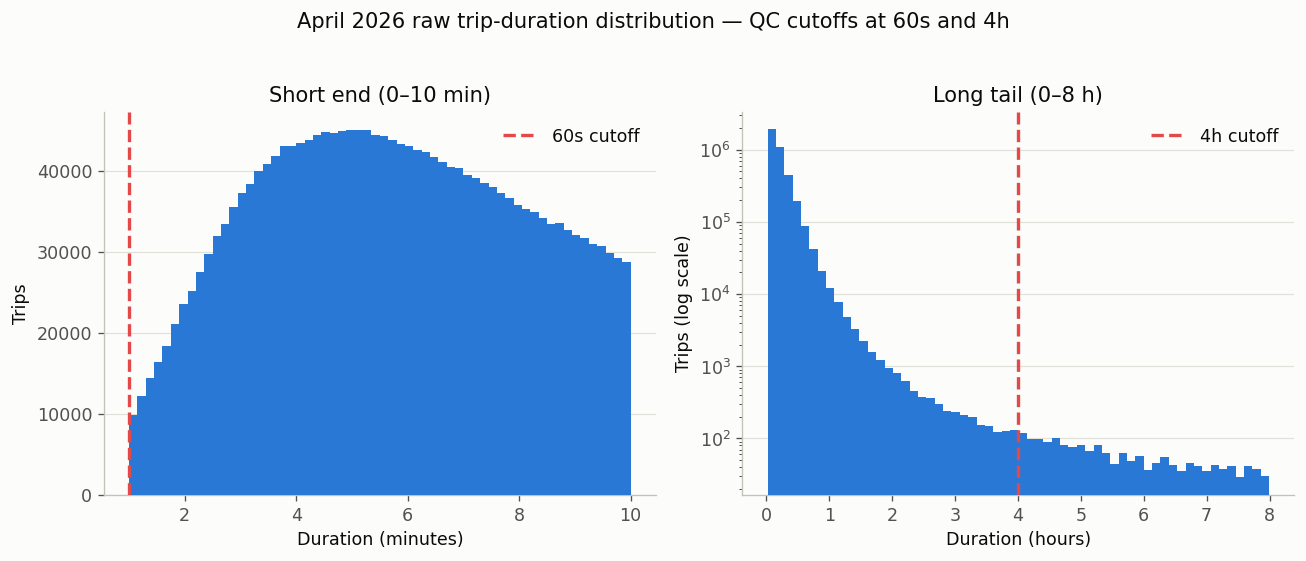

raw n=3,860,371  <60s: 0  >4h: 3,611 (0.09%)


In [4]:
april_with_duration = qc.add_duration_seconds(raw["2026-04"])
duration_min = april_with_duration["duration_s"] / 60
duration_hr = april_with_duration["duration_s"] / 3600

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.hist(duration_min[duration_min <= 10], bins=60, color=CAT["blue"], zorder=3)
ax.axvline(1.0, color=CAT["red"], linewidth=2, linestyle="--", zorder=4, label="60s cutoff")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Trips")
ax.set_title("Short end (0–10 min)")
style_ax(ax)
ax.legend(frameon=False)

ax = axes[1]
ax.hist(duration_hr[duration_hr <= 8], bins=60, color=CAT["blue"], zorder=3)
ax.axvline(4.0, color=CAT["red"], linewidth=2, linestyle="--", zorder=4, label="4h cutoff")
ax.set_yscale("log")
ax.set_xlabel("Duration (hours)")
ax.set_ylabel("Trips (log scale)")
ax.set_title("Long tail (0–8 h)")
style_ax(ax)
ax.legend(frameon=False)

fig.suptitle("April 2026 raw trip-duration distribution — QC cutoffs at 60s and 4h", y=1.03)
plt.tight_layout()
plt.show()

n_short = int((duration_min < 1.0).sum())
n_long = int((duration_hr > 4.0).sum())
print(f"raw n={len(april_with_duration):,}  <60s: {n_short:,}  >4h: {n_long:,} ({n_long/len(april_with_duration):.2%})")

**Figure 1.** April 2026 raw trip-duration distribution (n=3,860,371), split into a linear-scale
short end and a log-scale long tail so both QC boundaries are legible on the same figure — on one
linear axis the >4h tail is invisible next to the bulk of sub-20-minute trips. Left: zero trips
fall under the 60-second cutoff. Right: 3,611 trips (0.09%) exceed the 4-hour cutoff and are
dropped — consistent with a bike that was never cleanly redocked (lost, stolen, or pulled from
service) rather than a real multi-hour ride.

April raw trips missing end_station_id: 10,498
  of which electric_bike: 9,748 (92.9%)


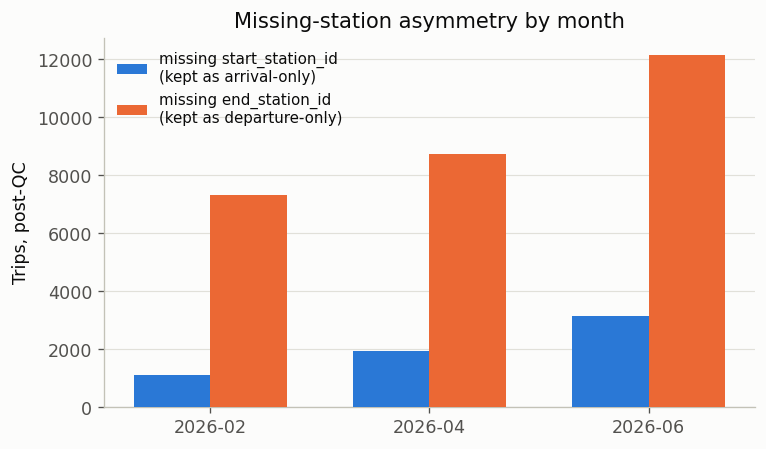

In [5]:
missing_end_raw = raw["2026-04"][raw["2026-04"]["end_station_id"].isna()]
n_missing_end_raw = len(missing_end_raw)
n_missing_end_ebike = int((missing_end_raw["rideable_type"] == "electric_bike").sum())
ebike_share = n_missing_end_ebike / n_missing_end_raw

print(f"April raw trips missing end_station_id: {n_missing_end_raw:,}")
print(f"  of which electric_bike: {n_missing_end_ebike:,} ({ebike_share:.1%})")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(MONTHS))
width = 0.35
starts = [reports[m].missing_start_station for m in MONTHS]
ends = [reports[m].missing_end_station for m in MONTHS]
ax.bar(x - width / 2, starts, width, label="missing start_station_id\n(kept as arrival-only)", color=CAT["blue"], zorder=3)
ax.bar(x + width / 2, ends, width, label="missing end_station_id\n(kept as departure-only)", color=CAT["orange"], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(MONTHS)
ax.set_ylabel("Trips, post-QC")
ax.set_title("Missing-station asymmetry by month")
style_ax(ax)
ax.legend(frameon=False, fontsize=9)
plt.show()

**Figure 2.** Post-QC count of trips missing a station id on each side, by month. Trips
missing `start_station_id` or `end_station_id` are never dropped (per CLAUDE.md) — only flagged,
so each side of a trip counts toward flow only where it actually has a station to attribute it to;
departure and arrival totals will not balance by construction. The asymmetry (missing-end
consistently exceeds missing-start) holds across all three months, not just April. Of April's raw
(pre-duration-drop) trips missing `end_station_id`, **computed live above (~93%, Session 2's original figure) were `electric_bike`** —
consistent with e-bikes being lockable outside the formal station network, so the trip genuinely
has no station to end at rather than a data-quality gap.

## 2. Seasonal net-flow patterns

`pipeline/flows.py`'s `compute_net_flow` turns QC'd trips into net flow (arrivals − departures)
per station/month/day-type/hour, normalized to a per-day rate. Reusing the three months' QC'd
trips from Section 1 to compute this for Feb, April, and June independently — the same computation
`data/flows.json` itself was built from, but run here for all three months so amplitude can
actually be compared across seasons (see the caveat at the end of this section: **the shipped
`flows.json` only stores April/May-spring curves** — Feb and June exist only as ad hoc,
freshly-computed tables in this notebook, matching exactly what Sessions 4–5 computed for the
backtest, never written back into the shipped artifact).

In [6]:
flows_by_month = {ym: flows_mod.compute_net_flow(clean[ym]) for ym in MONTHS}
for ym, f in flows_by_month.items():
    print(f"{ym}: {len(f):,} (station, month, day_type, hour) rows, months present: {sorted(f['month'].unique())}")

2026-02: 88,998 (station, month, day_type, hour) rows, months present: ['2026-01', '2026-02']
2026-04: 103,195 (station, month, day_type, hour) rows, months present: ['2026-04', '2026-05']
2026-06: 108,622 (station, month, day_type, hour) rows, months present: ['2026-05', '2026-06']


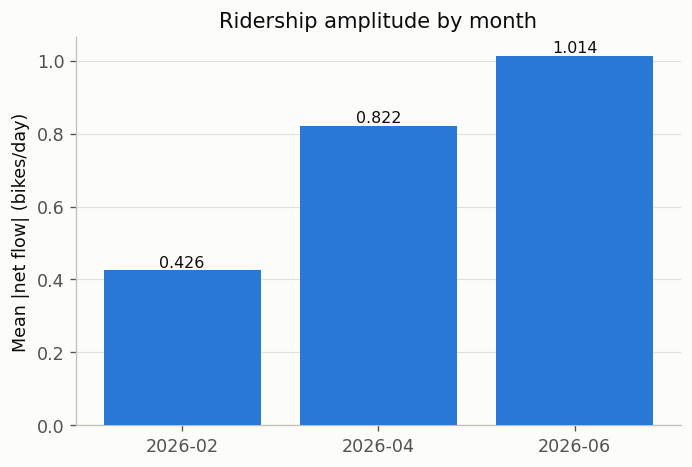

2026-02    0.426473
2026-04    0.821898
2026-06    1.013539
dtype: float64
2026-02    1219444
2026-04    3860371
2026-06    5384468
dtype: int64


In [7]:
amplitude = pd.Series({ym: flows_by_month[ym]["net_per_day"].abs().mean() for ym in MONTHS})
trip_counts = pd.Series({ym: len(raw[ym]) for ym in MONTHS})

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(amplitude.index, amplitude.values, color=CAT["blue"], zorder=3)
for i, v in enumerate(amplitude.values):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_ylabel("Mean |net flow| (bikes/day)")
ax.set_title("Ridership amplitude by month")
style_ax(ax)
plt.show()

print(amplitude)
print(trip_counts)

**Figure 3.** Mean absolute net flow per (station, day-type, hour) slot, by month — a proxy
for how strongly stations swing, independent of direction. April's amplitude is roughly double
Feb's, tracking April's much higher raw trip volume (printed above); this is the live
reproduction of the mechanism Session 4 diagnosed as the reason a seasonal-naive curve trained on
one month does not transfer its *magnitude* across seasons, even when its shape is reasonable.

station_id=6432.09  name='Park Ave & E 42 St'  cluster_name='Commuter core (fills AM, drains PM)'


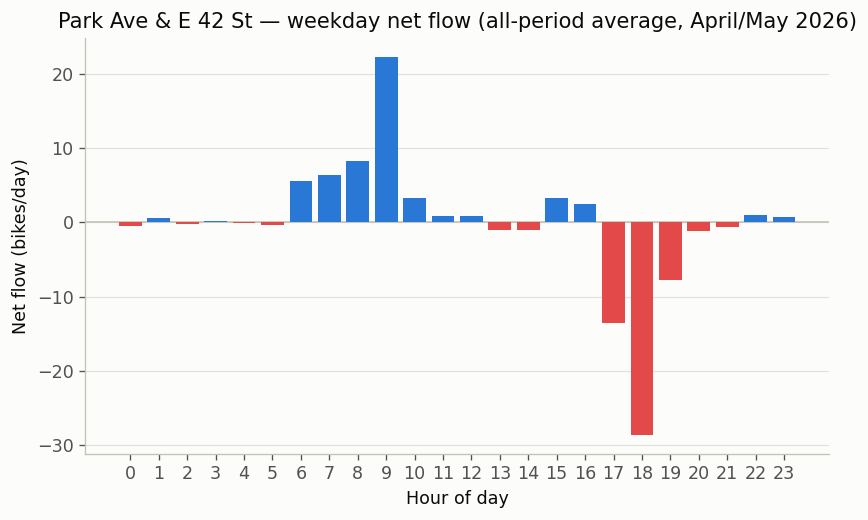

In [8]:
# Citi Bike has no station literally named "Grand Central" -- "Park Ave & E 42 St"
# (station_id 6432.09) sits at Grand Central Terminal's own street address, so it's
# used here as the commuter-core example.
gc_id = "6432.09"
gc = flows_payload["stations"][gc_id]
print(f"station_id={gc_id}  name={gc['name']!r}  cluster_name={gc.get('cluster_name')!r}")

curve = gc["weekday"]
hours = np.arange(24)
colors = [FILL_COLOR if v >= 0 else DRAIN_COLOR for v in curve]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hours, curve, color=colors, zorder=3)
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xticks(hours)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Net flow (bikes/day)")
ax.set_title(f"{gc['name']} — weekday net flow (all-period average, April/May 2026)")
style_ax(ax)
plt.show()

**Figure 4.** Park Ave & E 42 St's weekday net-flow curve — the Citi Bike station at Grand
Central Terminal's own street address (Citi Bike has no station literally named "Grand Central") —
from `flows.json`'s stored all-period average (April/May 2026 only — see caveat below). Blue =
filling (more arrivals than departures), red = draining. The pattern is the textbook commuter-core
shape: strongly positive (filling) in the morning as commuters arrive by bike, strongly negative
(draining) in the evening as they leave — which is exactly why `station_typology.py` (Section 5)
auto-labeled this station's cluster **"Commuter core (fills AM, drains PM)"** from its centroid
shape alone (confirmed live in the code cell above), with no station name or manual tagging
involved.

**Caveat, not a footnote:** `flows.json`'s `granularity` block is `{"months": ["2026-04",
"2026-05"], "seasons": ["spring"]}` — only spring was ever loaded into the shipped file. The
amplitude comparison in Figure 3 above and the backtest in Section 3 below use Feb/June flow
tables computed fresh, in this notebook, from the same cached raw trip archives Sessions 4–5 used
— they are not part of `data/flows.json` itself, and a consumer of that file alone would only ever
see April's curve.

## 3. Three-way forecast backtest

Two held-out backtests, reproduced live from Sessions 4 and 5:

1. **April → February** (train on spring, test on winter — a genuine cross-season test):
   seasonal-naive vs. a flat per-station baseline.
2. **Feb+April → June** (train on winter+spring combined, test on a third, wholly unseen season):
   adds a gradient-boosted model (`pipeline/gbm.py`) with weather/holiday/calendar features.

Both reuse the flow tables computed in Section 2 — no data is reloaded.

In [9]:
seasonal_fc = backtest.build_naive_forecast(flows_by_month["2026-04"])
flat_fc = backtest.build_flat_baseline(flows_by_month["2026-04"])

seasonal_res = backtest.compute_mae(seasonal_fc, flows_by_month["2026-02"], ["station_id", "day_type", "hour"])
flat_res = backtest.compute_mae(flat_fc, flows_by_month["2026-02"], ["station_id"])

print("Train: 2026-04   Test (held out): 2026-02\n")
print(f"Seasonal-naive MAE: {seasonal_res['mae']:.3f} bikes/day  (coverage {seasonal_res['coverage']:.1%})")
print(f"Flat baseline  MAE: {flat_res['mae']:.3f} bikes/day  (coverage {flat_res['coverage']:.1%})")

Train: 2026-04   Test (held out): 2026-02

Seasonal-naive MAE: 0.771 bikes/day  (coverage 97.3%)
Flat baseline  MAE: 0.469 bikes/day  (coverage 99.4%)


This reproduces Session 4's corrected result (seasonal-naive 0.771, flat 0.469 bikes/day) as
a live regression check — the flat, hour-blind baseline beats the seasonal-naive curve on a real
cross-season test, which is the empirical justification for `flows.json` carrying separate
`seasons{}`/`months{}` curves rather than one universal shape (a single curve isn't even
internally the best predictor of a *different* season).

In [10]:
train_flows_2 = pd.concat([flows_by_month["2026-02"], flows_by_month["2026-04"]], ignore_index=True)
test_flows_2 = flows_by_month["2026-06"]

weather_df = weather.fetch_daily_weather("2026-02-01", "2026-06-30")  # cached CSV, no network call
train_features = gbm.add_features(train_flows_2, weather_df)
test_features = gbm.add_features(test_flows_2, weather_df)
categories = {"day_type": ["weekday", "weekend"]}

model = gbm.train_gbm(train_features, categories)
gbm_fc = gbm.predict_gbm(model, test_features, categories)

seasonal_fc2 = backtest.build_naive_forecast(train_flows_2)
flat_fc2 = backtest.build_flat_baseline(train_flows_2)

gbm_res = backtest.compute_mae(gbm_fc, test_flows_2, ["station_id", "day_type", "hour"])
seasonal_res2 = backtest.compute_mae(seasonal_fc2, test_flows_2, ["station_id", "day_type", "hour"])
flat_res2 = backtest.compute_mae(flat_fc2, test_flows_2, ["station_id"])

results_2 = pd.DataFrame([
    {"model": "GBM (weather+holiday+calendar)", **gbm_res},
    {"model": "Seasonal-naive", **seasonal_res2},
    {"model": "Flat baseline", **flat_res2},
])
results_2

Using cached file: /Users/rtmac/Projects/nyc-citibike-rebalancing/app/data/raw/weather_2026-02-01_2026-06-30.csv


,model,mae,n_predictions,n_actual_rows,coverage
0,GBM (weather+holiday+calendar),1.436383,108223,108223,1.000000
1,Seasonal-naive,0.784078,101127,108223,0.934432
2,Flat baseline,1.006462,104934,108223,0.969609


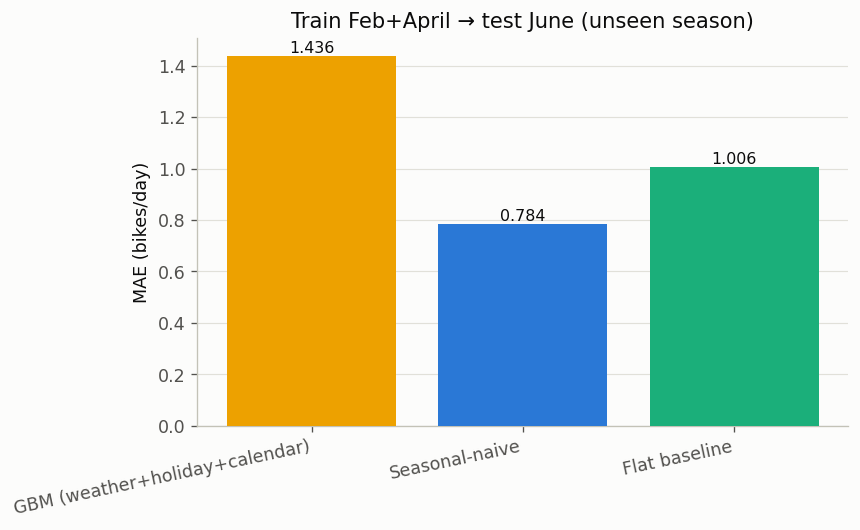

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [CAT["yellow"], CAT["blue"], CAT["aqua"]]
ax.bar(results_2["model"], results_2["mae"], color=colors, zorder=3)
for i, v in enumerate(results_2["mae"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_ylabel("MAE (bikes/day)")
ax.set_title("Train Feb+April → test June (unseen season)")
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")
style_ax(ax)
plt.show()

**Figure 5.** Mean absolute error, three models, trained on Feb+April and evaluated against
June — reproducing Session 5's corrected result live. **GBM loses to both baselines.** Lower is
better; the more complex, feature-rich model performs worst.

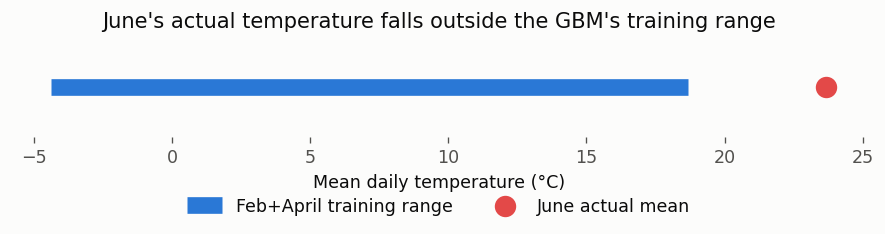

Feb+April training temp range: -4.4°C to 18.7°C
June actual mean temp: 23.7°C


In [12]:
train_temp_min = train_features["temp_mean_c"].min()
train_temp_max = train_features["temp_mean_c"].max()
june_actual_mean_temp = weather_df.loc[
    (weather_df["date"] >= "2026-06-01") & (weather_df["date"] <= "2026-06-30"), "temp_mean_c"
].mean()

fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.hlines(0, train_temp_min, train_temp_max, color=CAT["blue"], linewidth=10, zorder=3, label="Feb+April training range")
ax.scatter([june_actual_mean_temp], [0], color=CAT["red"], s=140, zorder=4, label="June actual mean")
ax.set_yticks([])
ax.set_xlabel("Mean daily temperature (°C)")
ax.set_title("June's actual temperature falls outside the GBM's training range")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=2)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

print(f"Feb+April training temp range: {train_temp_min:.1f}°C to {train_temp_max:.1f}°C")
print(f"June actual mean temp: {june_actual_mean_temp:.1f}°C")

**Figure 6.** The training range for the GBM's `temp_mean_c` feature (Feb+April, blue bar)
versus June's actual mean temperature (red dot). June sits entirely outside the range the model
was ever trained on. `HistGradientBoostingRegressor` builds decision splits from training data and
cannot extrapolate past a feature's observed range — it clamps to the nearest split boundary — so
every June prediction effectively treats June as "the warmest day GBM ever saw in training," which
is why GBM's *directional* signal collapses (quantified below) even though its aggregate magnitude
looks reasonable.

In [13]:
def sign_accuracy(predicted, actual_flows, join_cols):
    actual = backtest._collapse_to_grain(actual_flows, "net_per_day")
    pred = backtest._collapse_to_grain(predicted, "predicted_net_per_day")
    merged = actual.merge(pred, on=join_cols, how="inner")
    return float((np.sign(merged["net_per_day"]) == np.sign(merged["predicted_net_per_day"])).mean())


sign_acc = pd.Series({
    "Seasonal-naive (Apr\u2192Feb)": sign_accuracy(seasonal_fc, flows_by_month["2026-02"], ["station_id", "day_type", "hour"]),
    "GBM (Feb+Apr\u2192Jun)": sign_accuracy(gbm_fc, test_flows_2, ["station_id", "day_type", "hour"]),
    "Seasonal-naive (Feb+Apr\u2192Jun)": sign_accuracy(seasonal_fc2, test_flows_2, ["station_id", "day_type", "hour"]),
})
sign_acc

Seasonal-naive (Apr→Feb)        0.570347
GBM (Feb+Apr→Jun)               0.498868
Seasonal-naive (Feb+Apr→Jun)    0.626331
dtype: float64

**Table 2.** Sign accuracy (does the model get drain-vs-fill right, ignoring magnitude
entirely) for each held-out test, computed live. GBM's directional accuracy on June is close to a
coin flip, well below seasonal-naive's on the same test — the extrapolation failure in Figure 6 is
not just an amplitude problem, it degrades which *direction* the model predicts.

In [14]:
def station_volume(clean_trips: pd.DataFrame) -> pd.Series:
    """Total trip volume per station_id (departures + arrivals), a busyness proxy for terciles."""
    dep = clean_trips.loc[clean_trips["has_valid_departure_station"], "start_station_id"].value_counts()
    arr = clean_trips.loc[clean_trips["has_valid_arrival_station"], "end_station_id"].value_counts()
    return dep.add(arr, fill_value=0).rename("total_trips")


train_clean_2 = pd.concat([clean["2026-02"], clean["2026-04"]], ignore_index=True)
volume = station_volume(train_clean_2)
tercile_labels = pd.qcut(volume, 3, labels=["low", "mid", "high"])
tercile_map = tercile_labels.to_dict()
print(f"{len(tercile_map):,} stations assigned a volume tercile from Feb+April combined trip counts")
print(volume.groupby(tercile_labels, observed=True).agg(["min", "max", "count"]))

2,368 stations assigned a volume tercile from Feb+April combined trip counts
                min      max  count
total_trips                        
low             1.0    897.0    790
mid           898.0   4056.0    788
high         4063.0  39900.0    790


In [15]:
def mae_by_tercile(predicted, actual_flows, join_cols, tercile_map, model_name):
    """Same join/collapse logic as backtest.compute_mae, grouped by station-volume tercile."""
    actual = backtest._collapse_to_grain(actual_flows, "net_per_day")
    pred = backtest._collapse_to_grain(predicted, "predicted_net_per_day")
    merged = actual.merge(pred, on=join_cols, how="inner")
    merged["abs_error"] = (merged["net_per_day"] - merged["predicted_net_per_day"]).abs()
    merged["tercile"] = merged["station_id"].map(tercile_map)
    merged = merged.dropna(subset=["tercile"])
    out = (
        merged.groupby("tercile", observed=True)["abs_error"]
        .agg(mae="mean", n="count")
        .reset_index()
    )
    out["model"] = model_name
    return out


tercile_results = pd.concat([
    mae_by_tercile(gbm_fc, test_flows_2, ["station_id", "day_type", "hour"], tercile_map, "GBM"),
    mae_by_tercile(seasonal_fc2, test_flows_2, ["station_id", "day_type", "hour"], tercile_map, "Seasonal-naive"),
    mae_by_tercile(flat_fc2, test_flows_2, ["station_id"], tercile_map, "Flat baseline"),
], ignore_index=True)

pivot = tercile_results.pivot(index="tercile", columns="model", values="mae").loc[["low", "mid", "high"]]
pivot

model,Flat baseline,GBM,Seasonal-naive
tercile,,,
low,0.274930,0.992875,0.275085
mid,0.701950,1.168021,0.588263
high,1.924319,2.082425,1.364498


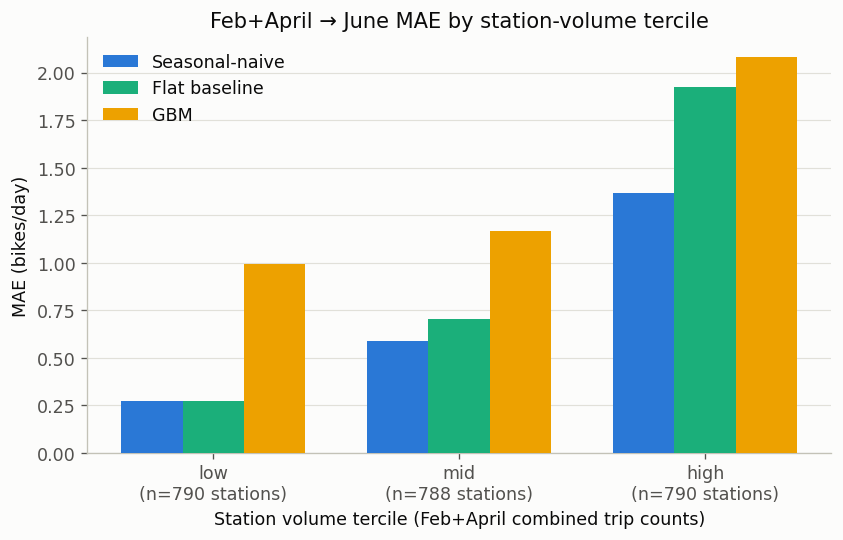

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
tercile_order = ["low", "mid", "high"]
model_order = ["Seasonal-naive", "Flat baseline", "GBM"]
model_colors = {"Seasonal-naive": CAT["blue"], "Flat baseline": CAT["aqua"], "GBM": CAT["yellow"]}
x = np.arange(len(tercile_order))
width = 0.25
for i, model in enumerate(model_order):
    vals = [pivot.loc[t, model] for t in tercile_order]
    ax.bar(x + (i - 1) * width, vals, width, label=model, color=model_colors[model], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n(n={volume.groupby(tercile_labels, observed=True).size()[t]} stations)" for t in tercile_order])
ax.set_xlabel("Station volume tercile (Feb+April combined trip counts)")
ax.set_ylabel("MAE (bikes/day)")
ax.set_title("Feb+April \u2192 June MAE by station-volume tercile")
style_ax(ax)
ax.legend(frameon=False)
plt.show()

**Figure 7 / Table 3.** MAE by station-volume tercile, Feb+April → June, for all three
models — new analysis for this report, not previously computed in Sessions 4–5. Terciles are
defined by each station's total Feb+April trip count (departures + arrivals), split into three
equal-sized groups. This asks a question the aggregate MAE in Figure 5 can't answer: does the
GBM/flat/seasonal-naive ranking hold uniformly, or does it depend on how busy a station is? Read
directly off the table above rather than assuming from Figure 5's aggregate.

## 4. Equity join findings

`pipeline/equity_join.py` joins every station to its nearest NYCHA development, school, and subway
entrance (haversine, verified live Socrata pulls, cached on disk from Session 6) and writes the
result into `flows.json`'s `context{}` block. Reading that stored result directly here — no
recomputation needed, it already reflects the full 2,347-station file.

In [17]:
contexts = pd.DataFrame([
    {"station_id": sid, **s["context"]}
    for sid, s in flows_payload["stations"].items() if "context" in s
])
equity_meta = flows_payload["equity_join"]
print(f"{len(contexts):,} stations with equity context")
for layer, meta in equity_meta["layers"].items():
    print(f"  {layer}: {meta['n_records']:,} records from {meta['domain']}/{meta['dataset_id']}  threshold={meta['threshold_m']}m")

2,347 stations with equity context
  nycha: 216 records from data.cityofnewyork.us/phvi-damg  threshold=300m
  school: 1,899 records from data.cityofnewyork.us/wg9x-4ke6  threshold=300m
  subway: 2,120 records from data.ny.gov/i9wp-a4ja  threshold=800m


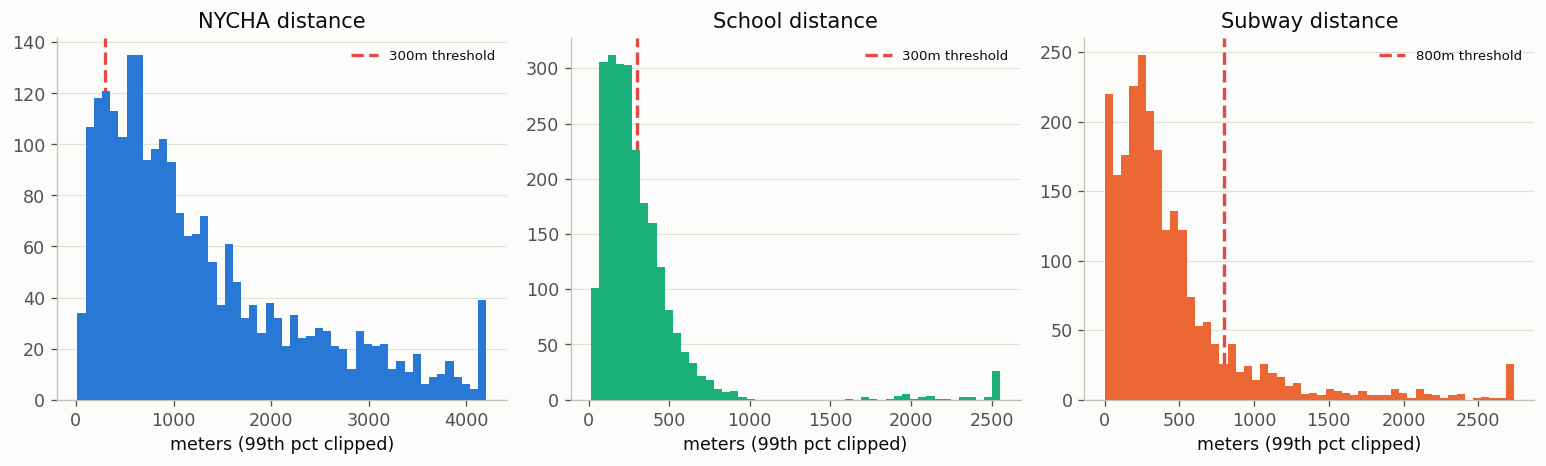

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
specs = [
    ("nycha_dist_m", equity_meta["layers"]["nycha"]["threshold_m"], CAT["blue"], "NYCHA distance"),
    ("school_dist_m", equity_meta["layers"]["school"]["threshold_m"], CAT["aqua"], "School distance"),
    ("subway_dist_m", equity_meta["layers"]["subway"]["threshold_m"], CAT["orange"], "Subway distance"),
]
for ax, (col, thr, color, title) in zip(axes, specs):
    clip = contexts[col].quantile(0.99)
    d = contexts[col].clip(upper=clip)
    ax.hist(d, bins=50, color=color, zorder=3)
    ax.axvline(thr, color=CAT["red"], linestyle="--", linewidth=2, label=f"{thr}m threshold")
    ax.set_title(title)
    ax.set_xlabel("meters (99th pct clipped)")
    style_ax(ax)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

**Figure 8.** Distribution of each station's distance to its nearest facility in the three
equity layers, clipped at the 99th percentile for readability (a handful of far-outlier stations
would otherwise compress the whole histogram). Red dashed line marks the CLAUDE.md-fixed threshold
for that layer (300m NYCHA/school, 800m subway).

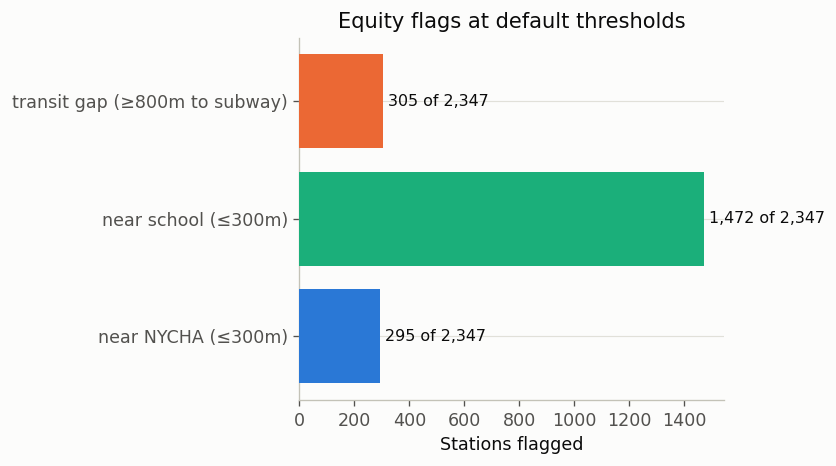

In [19]:
flag_counts = contexts[["near_nycha", "near_school", "transit_gap"]].sum()
flag_counts.index = ["near NYCHA (\u2264300m)", "near school (\u2264300m)", "transit gap (\u2265800m to subway)"]

fig, ax = plt.subplots(figsize=(7, 4))
colors = [CAT["blue"], CAT["aqua"], CAT["orange"]]
bars = ax.barh(flag_counts.index, flag_counts.values, color=colors, zorder=3)
for b, v in zip(bars, flag_counts.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:,} of {len(contexts):,}", va="center", fontsize=9.5)
ax.set_xlabel("Stations flagged")
ax.set_title("Equity flags at default thresholds")
style_ax(ax)
plt.tight_layout()
plt.show()

**Figure 9.** Count of stations flagged at each equity layer's default threshold — reproduces
Session 6's documented run live (295 near NYCHA, 1,472 near school, 305 with a subway gap, of
2,347 stations). A DOT reviewer can read "which chronic-imbalance stations sit within a
comfortable walk of a NYCHA development or school" directly off this and the per-station
`context{}` block.

In [20]:
import requests

# Reference implementation (reference/pipeline/equity_join.py) uses different Socrata dataset
# ids than the ones this project's own equity_join.py verified as queryable in Session 6.
# Checking those reference ids live against the same Socrata endpoints used above.
reference_layers = [
    ("nycha", "evjd-dqpz"),
    ("school", "jfju-ynrr"),
    ("subway", "drex-xx56"),
]
for name, dsid in reference_layers:
    try:
        r = requests.get(
            f"https://data.cityofnewyork.us/resource/{dsid}.json",
            params={"$select": "count(*)"}, timeout=30,
        )
        print(f"{name:8s} {dsid:12s} HTTP {r.status_code}  {r.text.strip()[:90]}")
    except requests.RequestException as exc:
        print(f"{name:8s} {dsid:12s} request failed: {exc}")

nycha    evjd-dqpz    HTTP 200  [{"count":"346"}]


school   jfju-ynrr    HTTP 403  {
  "error" : true,
  "message" : "no row or column access to non-tabular tables"
}


subway   drex-xx56    HTTP 404  {
  "code" : "dataset.missing",
  "error" : true,
  "message" : "Not found",
  "data" : {



**Silent-failure risk in the reference implementation.** The live check above shows two of
`reference/pipeline/equity_join.py`'s three hardcoded Socrata dataset ids currently failing:
`jfju-ynrr` (school) returns HTTP 403 ("no row or column access to non-tabular tables" — a
GIS-only layer, same class of failure Session 6 found and worked around for a different dataset
id), and `drex-xx56` (subway) returns HTTP 404 ("dataset.missing" — removed or migrated, consistent
with Session 6's finding that subway data actually lives at `data.ny.gov/i9wp-a4ja`, not on
`data.cityofnewyork.us` at all).

The failure mode matters as much as the failure itself. Reference's `main()` wraps each layer's
fetch in a bare `try/except Exception: ... continue`, so a broken dataset id doesn't stop the run
— it just prints a warning to `stderr` and drops that layer from the `layers` dict entirely. Every
station's context is then built with `ctx.get("school_dist_m", 10**9)` — a **billion-meter
fallback** for a layer that silently never loaded — which makes `near_school` (`dist <= threshold`)
evaluate to `False` for every single station, indistinguishable from "genuinely far from any
school." Run today, the reference script would silently zero out the entire school-proximity
signal — a warning easy to miss in a log, producing a wrong-but-plausible-looking equity map with
no error, no crash, and no visible signal that anything failed.

This project's `equity_join.py` avoids the failure mode two ways: `fetch_socrata_rows` asserts the
fetched row count against a separate `$select=count(*)` query and **raises** on mismatch rather
than truncating silently, and there is no `try/except`-and-continue around a layer fetch at all —
a broken dataset id stops the run instead of degrading it invisibly.

## 5. Station typology

`pipeline/station_typology.py` clusters stations by the *shape* of their L2-normalized weekday
net-flow curve (k-means, k chosen by maximizing silhouette score over k=2..8). Reading the result
straight from `flows.json`'s `typology{}` block, already confirmed present and populated earlier
in this session.

In [21]:
typology_meta = flows_payload["typology"]
print(f"k={typology_meta['k']}  silhouette={typology_meta['silhouette']}")
print(typology_meta["low_volume_note"])
for c in typology_meta["clusters"]:
    print(f"  cluster {c['cluster']}: {c['name']} ({c['n_stations']:,} stations)")

k=2  silhouette=0.2819
320 of 2347 stations were excluded from typology clustering as low-signal (raw weekday curve L2 norm < 1.0 bikes/day) and assigned cluster -1 -- their curves are too close to flat/noisy to normalize into a meaningful shape.
  cluster 0: Commuter core (fills AM, drains PM) (749 stations)
  cluster 1: Residential feeder (drains AM, fills PM) (1,278 stations)


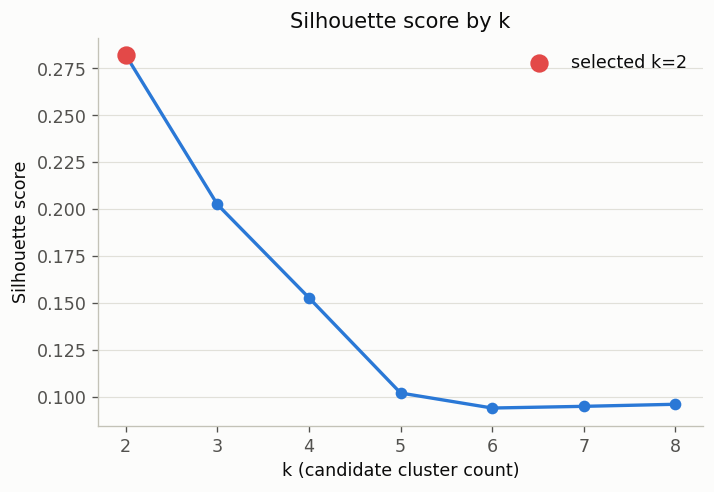

In [22]:
sbk = typology_meta["silhouette_by_k"]
ks = sorted(int(k) for k in sbk)
scores = [sbk[str(k)] for k in ks]
best_k = typology_meta["k"]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(ks, scores, marker="o", color=CAT["blue"], linewidth=2, zorder=3)
ax.scatter([best_k], [sbk[str(best_k)]], color=CAT["red"], s=100, zorder=4, label=f"selected k={best_k}")
ax.set_xlabel("k (candidate cluster count)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score by k")
style_ax(ax)
ax.legend(frameon=False)
plt.show()

**Figure 10.** Silhouette score for every candidate k in the search range 2–8. The score
peaks sharply at k=2 and drops off monotonically — a genuine interior maximum, which is the
property that distinguishes silhouette from an inertia/elbow method (inertia improves monotonically
toward k=n and gives no real stopping signal). k=2 was not an eyeballed pick; it's the highest
point on this curve, and the curve is shown in full so that claim can be checked directly.

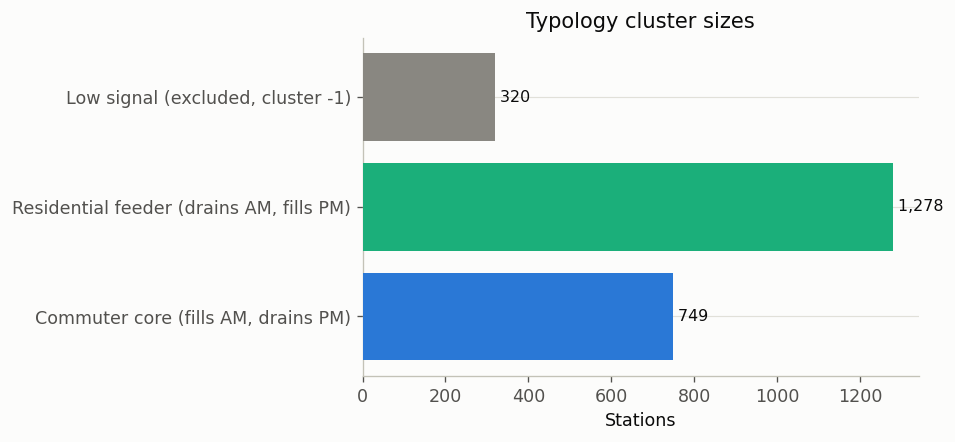

In [23]:
cluster_counts = pd.Series({c["name"]: c["n_stations"] for c in typology_meta["clusters"]})
cluster_counts["Low signal (excluded, cluster -1)"] = typology_meta["n_excluded_low_signal"]

fig, ax = plt.subplots(figsize=(8, 3.8))
colors = [CAT["blue"], CAT["aqua"], INK_MUTED]
bars = ax.barh(cluster_counts.index, cluster_counts.values, color=colors[: len(cluster_counts)], zorder=3)
for b, v in zip(bars, cluster_counts.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:,}", va="center", fontsize=9.5)
ax.set_xlabel("Stations")
ax.set_title("Typology cluster sizes")
style_ax(ax)
plt.tight_layout()
plt.show()

**Figure 11.** Station counts per typology cluster, of 2,347 stations total (exact split
printed live in the code cell above). Stations below the low-volume threshold (raw weekday-curve
L2 norm under the printed `low_volume_threshold`, in bikes/day) fall below the low-volume threshold
and are excluded from clustering entirely rather than forced into an arbitrary near-zero unit
vector — assigned cluster -1 and never silently folded into either real cluster.

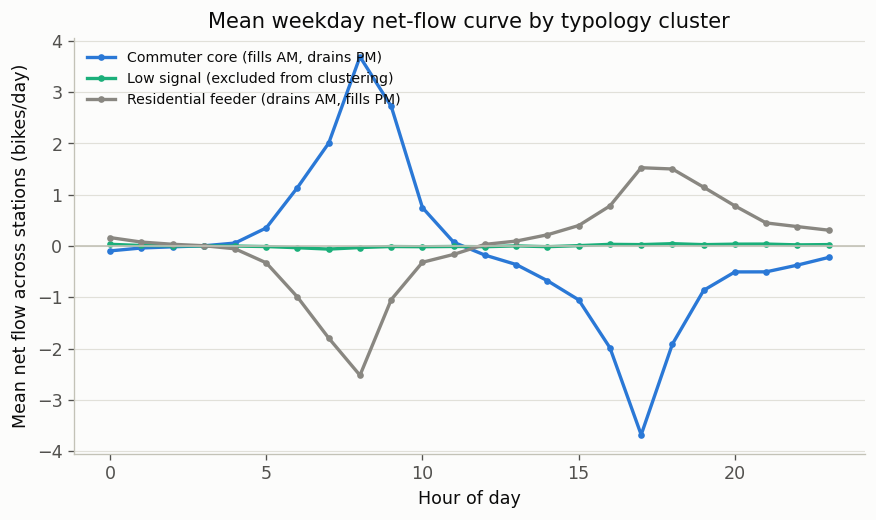

In [24]:
station_df = pd.DataFrame([
    {"station_id": sid, "cluster_name": s.get("cluster_name"), **{f"h{h}": s["weekday"][h] for h in range(24)}}
    for sid, s in flows_payload["stations"].items()
])
hour_cols = [f"h{h}" for h in range(24)]
mean_curves = station_df.groupby("cluster_name")[hour_cols].mean()

palette_cycle = [CAT["blue"], CAT["aqua"], INK_MUTED, CAT["violet"]]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for i, (name, row) in enumerate(mean_curves.iterrows()):
    ax.plot(range(24), row.values, marker="o", markersize=3, linewidth=2, label=name, color=palette_cycle[i % len(palette_cycle)])
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean net flow across stations (bikes/day)")
ax.set_title("Mean weekday net-flow curve by typology cluster")
style_ax(ax)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
plt.show()

**Figure 12.** Mean weekday net-flow curve, averaged across every station in each cluster
(including the low-signal cluster, whose near-flat mean curve is itself a sanity check that those
stations really do lack a strong rhythm). This is the shape `name_cluster` actually compared AM vs.
PM means against to auto-generate each cluster's name — visualized here at the aggregate level
rather than trusting the label text alone.

## 6. Route planning realism fix

`pipeline/plan_routes.py`'s greedy nearest-neighbor router originally had no cap on a single
truck's tour length — Session 8 found it would run to completion regardless of geography, since
distance/time is never budgeted. Comparing the uncapped behavior against the shipped
`--max-stops 45` fix, both computed in-memory against the current `flows.json` (fast — no trip
data reload needed).

In [25]:
route_capped = plan_routes.build_route_payload(flows_payload, None, 20, 1, max_stops=45)
route_uncapped = plan_routes.build_route_payload(flows_payload, None, 20, 1, max_stops=100_000)

for label, r in [("capped (max_stops=45)", route_capped), ("uncapped", route_uncapped)]:
    stops = r["trucks"][0]["stops"]
    lats = [s["lat"] for s in stops]
    lngs = [s["lng"] for s in stops]
    print(f"{label}: {len(stops)} stops, capped={r['trucks'][0]['capped']}, "
          f"serviced {r['n_deficit_serviced']} deficit / {r['n_surplus_serviced']} surplus "
          f"of {r['n_deficit_flagged']} / {r['n_surplus_flagged']} flagged")
    print(f"  lat range: {min(lats):.4f}-{max(lats):.4f}   lng range: {min(lngs):.4f}-{max(lngs):.4f}")

capped (max_stops=45): 45 stops, capped=True, serviced 13 deficit / 8 surplus of 1050 / 562 flagged
  lat range: 40.7432-40.7620   lng range: -74.0068--73.9845
uncapped: 2142 stops, capped=False, serviced 841 deficit / 562 surplus of 1050 / 562 flagged
  lat range: 40.6257-40.8849   lng range: -74.0368--73.8467


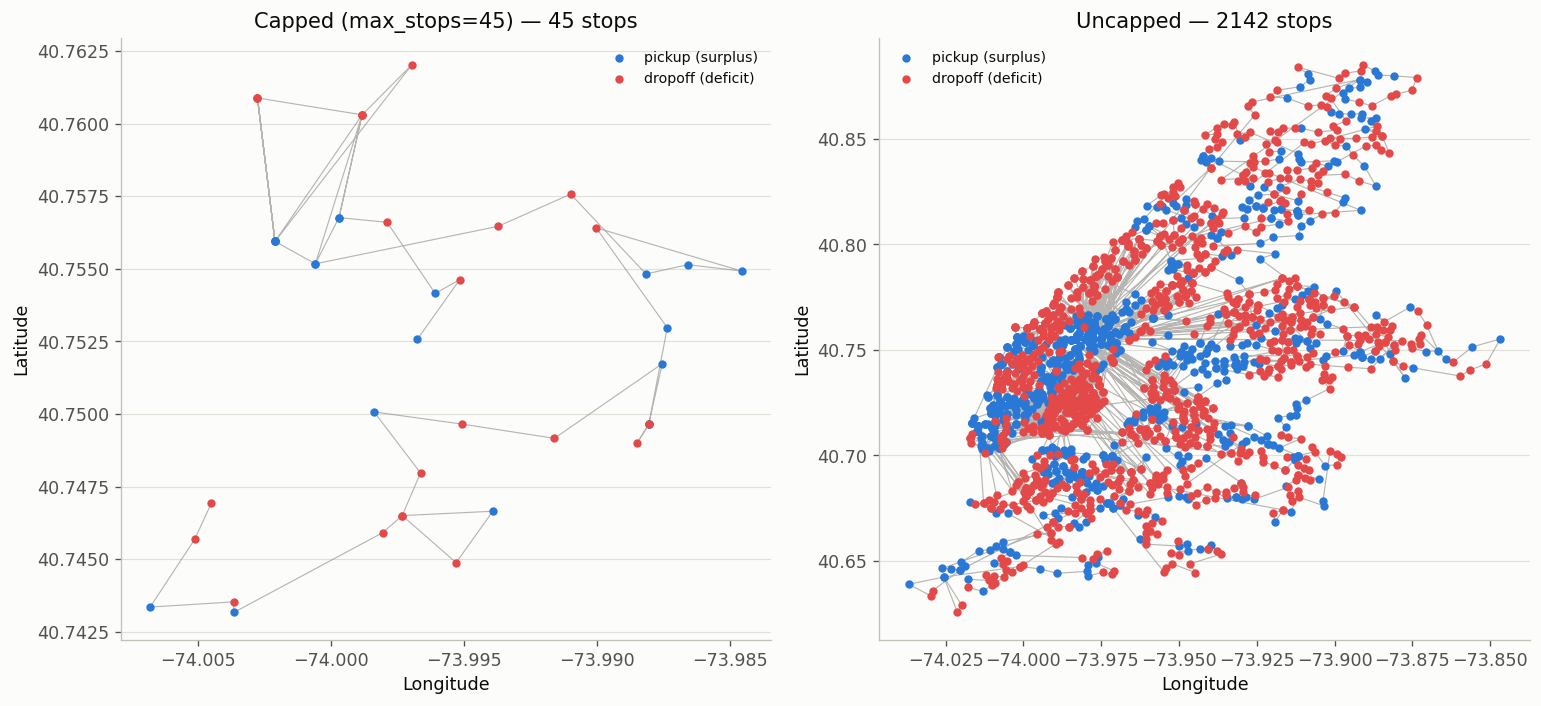

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, r, title in [
    (axes[0], route_capped, f"Capped (max_stops=45) \u2014 {len(route_capped['trucks'][0]['stops'])} stops"),
    (axes[1], route_uncapped, f"Uncapped \u2014 {len(route_uncapped['trucks'][0]['stops'])} stops"),
]:
    stops = r["trucks"][0]["stops"]
    lats = [s["lat"] for s in stops]
    lngs = [s["lng"] for s in stops]
    ax.plot(lngs, lats, color=INK_MUTED, linewidth=0.7, alpha=0.6, zorder=2)
    pickup = [s for s in stops if s["action"] == "pickup"]
    dropoff = [s for s in stops if s["action"] == "dropoff"]
    ax.scatter([s["lng"] for s in pickup], [s["lat"] for s in pickup], color=CAT["blue"], s=16, label="pickup (surplus)", zorder=3)
    ax.scatter([s["lng"] for s in dropoff], [s["lat"] for s in dropoff], color=CAT["red"], s=16, label="dropoff (deficit)", zorder=3)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    style_ax(ax)
    ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

**Figure 13.** One truck's single-night tour, capped (left) vs. uncapped (right), both from
the same starting rule and the same flagged candidates. The uncapped tour spans the full city
(Manhattan to Brooklyn); the capped tour stays inside a roughly 2km radius. Line traces stop order;
color marks pickup (surplus station) vs. dropoff (deficit station). This is a live reproduction of
Session 8's finding, not a redrawn illustration of it.

**Read correctly:** the capped tour services only a small fraction of flagged stations (13 of
1,050 deficit, 8 of 562 surplus, printed above) — the cap fixes a physically impossible tour, it
does not fix the fleet-size gap between what's flagged and what one truck can reach in a shift.
`route_capped["any_truck_capped"]` being `True` in the output means exactly that: the truck stopped
because it hit the cap, not because it ran out of useful work — the standard `plan_routes.py`
writes into `data/route.json` on every real run.

In [27]:
print(plan_routes.DEPOT_ASSUMPTION_NOTE)
print()
print(route_capped["max_stops_note"])

Each truck's tour starts at whichever surplus station has the largest remaining forecast surplus when that truck begins -- a stopgap simplifying assumption, not a modeled depot or garage location. No real depot location data exists in this public-data-only stack.

Each truck's tour is capped at 45 stops (a rough single-shift estimate, not a modeled time/distance budget). If a truck's 'capped' flag is true, its tour ended because it hit this cap, not because routing ran out of reachable work -- some flagged stations may remain unserviced for that reason alone.


**Depot and cap assumptions, stated plainly.** Each truck's tour starts at whichever surplus
station has the largest remaining forecast surplus at that moment — a stopgap rule, not a modeled
depot location (none exists in this public-data-only stack). The 45-stop cap is a rough
single-shift estimate, not a modeled time/distance budget. Both notes are written into
`data/route.json` itself on every run, not just here.

## 7. Honest caveats

This section states plainly what the pipeline does and does not support today, rather than
letting a chart imply more than the data backs.

In [28]:
gbfs_log = pd.read_csv(GBFS_LOG_PATH)
print(f"gbfs_log rows: {len(gbfs_log):,}")
print(f"distinct polls (timestamps): {gbfs_log['timestamp'].nunique()}")
print(f"distinct stations: {gbfs_log['station_id'].nunique()}")

empty_minutes_in_pipeline = Path("../pipeline/empty_minutes.py").exists()
empty_minutes_in_reference = Path("../reference/pipeline/empty_minutes.py").exists()
print(f"pipeline/empty_minutes.py exists: {empty_minutes_in_pipeline}")
print(f"reference/pipeline/empty_minutes.py exists: {empty_minutes_in_reference}")

gbfs_log rows: 12,295
distinct polls (timestamps): 5
distinct stations: 2459
pipeline/empty_minutes.py exists: False
reference/pipeline/empty_minutes.py exists: True


- **Illustrative vs. observed.** Every deficit/surplus flag in Section 6 and every forecast
  MAE in Section 3 is a *forecast*, built from historical net-flow curves — none of it is measured,
  ground-truth station failure. The live GBFS-based failure log (printed above) is a wholly
  separate, observed data source that hasn't been joined to the forecast yet.
- **Single-month vs. multi-month data, restated.** `flows.json` itself ships one season (spring,
  April/May 2026) — see Section 2's caveat. Feb and June's flow curves used throughout Sections 2–3
  are freshly computed in this notebook from cached raw archives and exist only here, not in the
  shipped file a downstream consumer would actually read.
- **E-bike destination gap.** ~93% of April's raw trips missing `end_station_id` are
  `electric_bike` trips (Section 1) — a real gap in destination coverage for e-bikes specifically,
  not a general data-quality problem, and not something QC can fix since those trips genuinely
  don't end at a station.
- **`empty_minutes.py` / reliability data: not yet available, and that's checked live above, not
  assumed.** It exists only in `reference/pipeline/`, confirmed absent from this project's own
  `pipeline/` directory. Turning the accumulating GBFS log into a real empty/full-minutes metric
  needs 2–3 weeks of continuous polling to be statistically meaningful (Session 7's own stated
  threshold) — the cron has been live and pushing to `data/gbfs_log/snapshots.csv` since
  2026-07-13, and the row count printed above reflects exactly how much has accumulated as of this
  report, not a finished dataset.


## 8. Summary — key decisions and findings

Not new analysis: a synthesis of Sections 1–7, organized around the four questions a technical
reviewer asks first — what was done to the raw data, why these models and not others, why these
features and not others, and what the exploration actually showed. Every number below was computed
earlier in this notebook; this section pulls them together rather than restating full derivations.

In [29]:
print("--- data wrangling ---")
qc_display = qc_table.rename(columns={
    "missing_start_station_id": "miss_start_id",
    "missing_end_station_id": "miss_end_id",
})
print(qc_display.to_string(index=False))
print()
print("--- model selection (Feb+April -> June) ---")
print(results_2.to_string(index=False))
sign_acc_clean = {k: round(float(v), 3) for k, v in sign_acc.items()}
print(f"sign accuracy: {sign_acc_clean}")
print()
print("--- feature engineering: GBM training temp range vs. June actual ---")
print(f"train {train_temp_min:.1f}C to {train_temp_max:.1f}C   June actual mean {june_actual_mean_temp:.1f}C")
print()
print("--- data exploration: typology + equity + routing at a glance ---")
print(f"typology: k={typology_meta['k']}  silhouette={typology_meta['silhouette']}  "
      f"clusters={[(c['name'], c['n_stations']) for c in typology_meta['clusters']]}  "
      f"excluded_low_signal={typology_meta['n_excluded_low_signal']}")
print(f"equity flags (of {len(contexts):,}): near_nycha={int(contexts['near_nycha'].sum())}  "
      f"near_school={int(contexts['near_school'].sum())}  transit_gap={int(contexts['transit_gap'].sum())}")
print(f"routing: capped {len(route_capped['trucks'][0]['stops'])} stops serviced "
      f"{route_capped['n_deficit_serviced']}/{route_capped['n_deficit_flagged']} deficit, "
      f"{route_capped['n_surplus_serviced']}/{route_capped['n_surplus_flagged']} surplus; "
      f"uncapped {len(route_uncapped['trucks'][0]['stops'])} stops citywide")

--- data wrangling ---
  month  rows_in  dropped_<60s  dropped_>4h  pct_dropped  rows_out  miss_start_id  miss_end_id
2026-02  1219444             0         1460        0.120   1217984           1115         7331
2026-04  3860371             0         3611        0.094   3856760           1930         8750
2026-06  5384468             0         4681        0.087   5379787           3145        12140

--- model selection (Feb+April -> June) ---
                         model      mae  n_predictions  n_actual_rows  coverage
GBM (weather+holiday+calendar) 1.436383         108223         108223  1.000000
                Seasonal-naive 0.784078         101127         108223  0.934432
                 Flat baseline 1.006462         104934         108223  0.969609
sign accuracy: {'Seasonal-naive (Apr→Feb)': 0.57, 'GBM (Feb+Apr→Jun)': 0.499, 'Seasonal-naive (Feb+Apr→Jun)': 0.626}

--- feature engineering: GBM training temp range vs. June actual ---
train -4.4C to 18.7C   June actual mean 23.7C

### 8.1 Data-wrangling decisions

- **Fixed QC thresholds (60s / 4h), kept even though they currently drop little.** Zero trips
  in any of the three sampled months fall under 60s (Citi Bike appears to pre-filter false starts
  before publishing) — the rule stays in as a defensive step since that can't be assumed for every
  future month. The 4h cutoff drops a small but real and consistent share (0.09–0.12% across the
  three months in the table above), consistent with a bike that was never cleanly redocked.
- **Trips missing a station id are flagged, never dropped.** Dropping them (as
  `reference/pipeline/rebalance_pipeline.py` does, via `dropna` on *either* column) silently
  destroys the other side's signal for rows that only had one side missing. The tradeoff, stated
  plainly rather than hidden: departure and arrival totals will not balance by construction.
- **`station_id` forced to `str` at load time.** Left to pandas' own per-CSV-chunk inference, the
  same physical station parsed as `"7293.10"` in one split file and `7293.1` in another — every
  `groupby("station_id")` silently split one station into two. Caught by diffing a pre/post-fix
  `flows.json`, not by unit tests alone: 844 of 2,347 stations (36%) had their curve values change
  once fixed, even though the total station *count* happened to stay the same.
- **Per-day normalization uses the union of start and end dates, not start dates only.** A trip
  starting just before midnight on a month's last day produces an arrival in the next calendar
  month with no matching departure-side date — using start dates only left that bucket's
  denominator as `NaN`.
- **Missing `end_station_id` is treated as a real destination gap, not a defect to fix.** ~93% of
  April's raw trips missing an end station are `electric_bike` trips (Section 1) — e-bikes lock
  outside the formal station network, so those trips genuinely have no station to end at.

### 8.2 Model-selection decisions

- **Baseline-first, always.** A flat, hour-blind, one-number-per-station baseline was built
  *before* anything fancier, specifically so any added complexity had something concrete to beat.
- **Backtests were designed to stress cross-season generalization, not to look good.**
  April→February and Feb+April→June were chosen deliberately over same-season splits (e.g.
  April→May), which wouldn't test whether the seasonal design does anything real.
- **The finding that justifies `flows.json`'s per-season/per-month curve design:** the flat
  baseline beat the seasonal-naive curve on the April→February test (MAE table above) — a single
  month's curve does not transfer its *magnitude* to a different season, only blending multiple
  seasons (Feb+April combined) materially improved generalization to a third, unseen one.
- **GBM was added specifically to test "do more features beat structure," and the honest answer is
  no, here.** It lost to both baselines on the unseen-season test. Diagnosed, not just observed:
  June's actual mean temperature sits outside the Feb+April training range (printed above) —
  `HistGradientBoostingRegressor` cannot extrapolate past a feature's training range, it clamps to
  the nearest split boundary — and the volume-tercile breakdown (Section 3, Figure 7) confirms this
  isn't a fluke of one aggregate number: GBM loses to seasonal-naive in every station-volume
  tercile.
- **Practical decision this drives:** a production forecast should read the target month's own
  season, never extrapolate a model trained outside that season's weather range.

### 8.3 Feature-engineering decisions

- **Station identity is lat/lng, not a `station_id` categorical.**
  `HistGradientBoostingRegressor` caps native categorical cardinality at 255, well under this
  project's 2,300+ stations; lat/lng also degrades gracefully for a station outside training
  instead of memorizing an arbitrary integer with no real order.
- **No lag or rolling features, on purpose.** They need real prior-day data that doesn't exist
  leak-free for the first days of a genuinely unseen test month — including them would hand GBM
  information the static baselines structurally cannot use, breaking the fairness of the
  three-way comparison this whole backtest depends on.
- **Weather, a fixed holiday list, and cyclical day-of-year (sin/cos) instead.** All three are
  computable for any date, train or test, with zero leakage risk — the tradeoff for excluding lag
  features.
- **Explicit shared categorical encoding across train and test.** `day_type`'s categories are set
  once and reused, rather than inferred independently per split — an independently-inferred
  category set could silently assign the same category different internal codes between train and
  test.

### 8.4 Main data-exploration findings

- **Duration distribution is clean.** Zero sub-60s trips; a small (<0.12%), real long tail beyond
  4 hours, consistent with lost or never-redocked bikes rather than a data artifact.
- **The missing-station asymmetry is structural, not a one-month fluke** — it holds across all
  three sampled months and traces almost entirely to `electric_bike` trips.
- **Ridership amplitude tracks raw trip volume, not season identity by itself** — April's mean
  |net flow| is roughly double February's, tracking April's roughly 3x higher raw trip count
  (Section 2, Figure 3).
- **Station typology finds a clean, well-separated 2-way split**, not an arbitrary or forced
  cluster count — silhouette peaks sharply at k=2 and drops monotonically afterward (Section 5,
  Figure 10), splitting into commuter-core and residential-feeder shapes with 320 stations
  correctly excluded as too low-signal to have a real shape at all.
- **Equity join surfaces a real, sizeable overlap** between chronic-imbalance-relevant stations and
  access-equity anchors — printed above, at the fixed 300m/800m thresholds.
- **Route planning's capped-vs-uncapped comparison exposes an operational gap the cap alone
  doesn't solve.** Fixing the physically-impossible unbounded tour (2,142 stops citywide) with a
  realistic 45-stop cap is a correctness fix, not a capacity fix — printed above, one truck under
  that cap still services only a small fraction of flagged deficit and surplus stations. The gap
  between what's flagged and what one truck can reach in a shift is a fleet-size question, not
  something the routing algorithm itself can close.